# LangGraph Crash Course

This notebook shows three LangGraph examples.

## Agenda
1. Core blocks of LangGraph
2. Simple Graph
3. Graph with conditional edges
4. Deep Research Graph

In [19]:
from typing import Any, List
from IPython.display import Image, display
from langgraph.graph import StateGraph, END , START
from pydantic import BaseModel, Field

from typing_extensions import Annotated, List
from typing import Literal


import operator
import sys 

sys.path.insert(0,"../code")


In [20]:
from setup_utils import *

In [21]:


# Initialize tracer (no-op if optional instrumentation is not installed)
tracer

## About LangGraph

LangGraph is an open-source framework for building, managing, and deploying complex, stateful AI agents/workflow using a **graph** based architecture.

Graphs are composed of nodes, edges.

`Node`: python Functions.    

`Edges`: transition between nodes. Edges can be
- Serial
- Parallel
- Conditional

`State`: python object accessible during graph execution. Best to use an instance of TypedDict, dataclass, or pydantic class



## Graph 1: Simple Graph Example With Normal Edges

Given two numbers, can you calulate the sum of them and the product of them.


here is a simple pydantic model that will be used as for the graph state.

`a` and `b` will be used as inputs.

`total_sum` and `total_multiply` and `total_final` will store outputs

In [22]:
class MathState(BaseModel):
    a: int
    b: int
    
    total_sum: int | None = None
    total_multiply: int | None = None
    total_final: int | None = None

edges of a graph.

they take a state object as input and return a dictionary of outputs to be merged into the state.

because edges can be updated in parallel, you should not mutate the input

In [23]:
def compute_sum(state: MathState) -> MathState:
    return {"total_sum": state.a + state.b}

def compute_product(state: MathState) -> MathState:
    return {"total_multiply": state.a * state.b}

def compute_final(state: MathState) -> MathState:
    return {"total_final": state.total_sum + state.total_multiply}

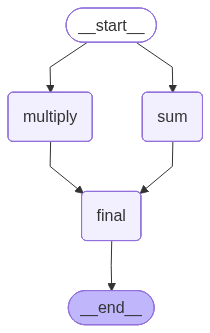

In [24]:
workflow_math = StateGraph(MathState)

workflow_math.add_node("sum", compute_sum)
workflow_math.add_node("multiply", compute_product)
workflow_math.add_node("final", compute_final)
workflow_math.add_edge(START, "sum")
workflow_math.add_edge(START, "multiply")

workflow_math.add_edge("sum", "final")
workflow_math.add_edge("multiply", "final")
workflow_math.add_edge("final", END)

graph_math = workflow_math.compile()
display(Image(graph_math.get_graph().draw_mermaid_png()))




In [25]:
with tracer.start_as_current_span("graph_math"):
    res = graph_math.invoke(MathState(a=2, b=5))

res

{'a': 2, 'b': 5, 'total_sum': 7, 'total_multiply': 10, 'total_final': 17}

## Graph 2: Graph Example With Conditional Edges

In [26]:
class ConditionalState(BaseModel):
    number: int
    final_message: str = None

In [27]:
def add_one_node(state:ConditionalState) -> ConditionalState:
    return {"number": state.number + 1}

def even_node(state:ConditionalState) -> ConditionalState:
    return {"final_message":"number is even"}

def odd_node(state:ConditionalState) -> ConditionalState:
    return {"final_message":"number is odd"}

def number_checker_condition(state:ConditionalState) ->Literal["even","odd"]:
    if state.number % 2 == 0:
        return "even"
    else:
        return "odd"

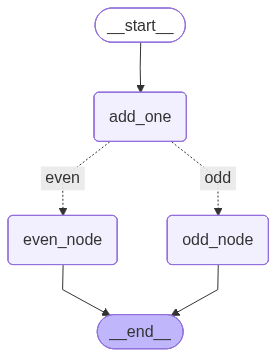

In [28]:
# Build the graph
workflow_conditional = StateGraph(ConditionalState)

# Add nodes
workflow_conditional.add_node("add_one", add_one_node)
workflow_conditional.add_node("even_node", even_node)
workflow_conditional.add_node("odd_node", odd_node)

workflow_conditional.add_edge(START, "add_one")
workflow_conditional.add_edge("odd_node",END)
workflow_conditional.add_edge("even_node",END)

# Add conditional edges depending on number
workflow_conditional.add_conditional_edges(
    "add_one",
    number_checker_condition,
    {"even": "even_node", "odd": "odd_node"}
)

# Compile the graph
graph_conditional = workflow_conditional.compile()
graph_conditional

In [29]:
with tracer.start_as_current_span("graph_conditional"):
    res = graph_conditional.invoke(ConditionalState(number=3))

res

{'number': 4, 'final_message': 'number is even'}

## Graph 3: Graph State Updates


Nodes can choose to update the state in various ways. 

Here is an example of a graph where nodes update the state by keeping track of the last visited node, as well as a list of all visited nodes using different methods.

In each node, you can choose to replace the current value , append , or apply any other operation.

Keep in mind that nodes in the graph may run in parallel.

In [30]:
class UpdatesState(BaseModel):
    last_visited_node: str = None
    
    
    all_visited_nodes_manually_updated:List[str] = []
    all_visited_nodes: Annotated[List[str], operator.add] = []




In [31]:
def node_a(state:UpdatesState) -> UpdatesState:
    return {"last_visited_node": "node_a"
            , "all_visited_nodes_manually_updated": state.all_visited_nodes_manually_updated + ["node_a"]
            , 'all_visited_nodes': ["node_a"]
    }

def node_b(state:UpdatesState) -> UpdatesState:
    return {"last_visited_node": "node_b"
            , "all_visited_nodes_manually_updated": state.all_visited_nodes_manually_updated + ["node_b"]
            , 'all_visited_nodes': ["node_b"]
    }

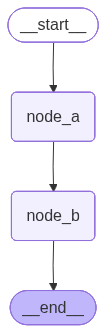

In [32]:
# Build the graph
workflow_state_updates = StateGraph(UpdatesState)

# Add nodes
workflow_state_updates.add_node("node_a", node_a)
workflow_state_updates.add_node("node_b", node_b)

workflow_state_updates.add_edge(START, "node_a")
workflow_state_updates.add_edge("node_a","node_b")

workflow_state_updates.add_edge("node_b",END)

# Compile the graph
graph_state_updates = workflow_state_updates.compile()
graph_state_updates

In [33]:
res = graph_state_updates.invoke(UpdatesState())
res


{'last_visited_node': 'node_b',
 'all_visited_nodes_manually_updated': ['node_a', 'node_b'],
 'all_visited_nodes': ['node_a', 'node_b']}

## Graph 4: Deep Research Flow
Takes an initial query, generates follow-up prompts, fabricates findings, then aggregates them.

In [34]:
class ResearchState(BaseModel):
    query: str
    sub_queries: List[str] = Field(default_factory=list)
    raw_notes: Annotated[list[str], operator.add] = []
    final_report: str = None

def expand_queries(state: ResearchState) -> dict[str, Any]:
    suggestions = [
        f"{state.query} overview",
        f"{state.query} challenges",
        f"{state.query} opportunities",
    ]
    return {"sub_queries": suggestions}

def gather_research(state: ResearchState) -> dict[str, Any]:
    raw_notes = [f"Research for '{item}': placeholder insight." for item in state.sub_queries]
    return {"raw_notes": raw_notes}

def summarize_research(state: ResearchState) -> dict[str, Any]:
    
    research_report = f"""
    # Introduction

    user queried about : {state.query}

    # Findings
    {state.raw_notes}

    # Conclusion
    {state.final_report}


    """
    
    return {"final_report": research_report}



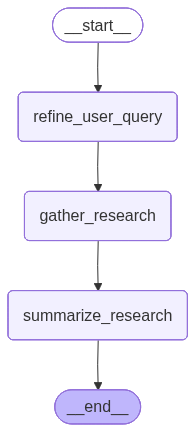

In [35]:
workflow_research = StateGraph(ResearchState)
workflow_research.add_node("refine_user_query", expand_queries)
workflow_research.add_node("gather_research", gather_research)
workflow_research.add_node("summarize_research", summarize_research)
workflow_research.set_entry_point("refine_user_query")
workflow_research.add_edge("refine_user_query", "gather_research")
workflow_research.add_edge("gather_research", "summarize_research")
workflow_research.add_edge("summarize_research", END)

graph_research = workflow_research.compile()
display(Image(graph_research.get_graph().draw_mermaid_png()))



In [36]:
graph_research.invoke(ResearchState(query="AI Agents"))



{'query': 'AI Agents',
 'sub_queries': ['AI Agents overview',
  'AI Agents challenges',
  'AI Agents opportunities'],
 'raw_notes': ["Research for 'AI Agents overview': placeholder insight.",
  "Research for 'AI Agents challenges': placeholder insight.",
  "Research for 'AI Agents opportunities': placeholder insight."],
 'final_report': '\n    # Introduction\n\n    user queried about : AI Agents\n\n    # Findings\n    ["Research for \'AI Agents overview\': placeholder insight.", "Research for \'AI Agents challenges\': placeholder insight.", "Research for \'AI Agents opportunities\': placeholder insight."]\n\n    # Conclusion\n    None\n\n\n    '}